In [1]:
# Unit homework.  problems 15.2 and 15.3 (pages 401-402)

In [2]:
# load required libraries
import os
import pandas as pd
from sklearn import preprocessing
from sklearn.metrics import pairwise
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
import matplotlib.pylab as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates

In [3]:
from pandas.core.apply import frame_apply
from sklearn.preprocessing import MinMaxScaler

In [4]:
# 15.2
pharm = pd.read_csv('Pharmaceuticals.csv')
pharm.shape

(21, 14)

In [5]:
print(pharm)

   Symbol                                Name  Market_Cap  Beta  PE_Ratio  \
0     ABT                 Abbott Laboratories       68.44  0.32      24.7   
1     AGN                      Allergan, Inc.        7.58  0.41      82.5   
2     AHM                        Amersham plc        6.30  0.46      20.7   
3     AZN                     AstraZeneca PLC       67.63  0.52      21.5   
4     AVE                             Aventis       47.16  0.32      20.1   
5     BAY                            Bayer AG       16.90  1.11      27.9   
6     BMY        Bristol-Myers Squibb Company       51.33  0.50      13.9   
7    CHTT                        Chattem, Inc        0.41  0.85      26.0   
8     ELN               Elan Corporation, plc        0.78  1.08       3.6   
9     LLY               Eli Lilly and Company       73.84  0.18      27.9   
10    GSK                 GlaxoSmithKline plc      122.11  0.35      18.0   
11    IVX                    IVAX Corporation        2.60  0.65      19.9   

In [6]:
pharm2 = pharm

In [7]:
print(pharm2)

   Symbol                                Name  Market_Cap  Beta  PE_Ratio  \
0     ABT                 Abbott Laboratories       68.44  0.32      24.7   
1     AGN                      Allergan, Inc.        7.58  0.41      82.5   
2     AHM                        Amersham plc        6.30  0.46      20.7   
3     AZN                     AstraZeneca PLC       67.63  0.52      21.5   
4     AVE                             Aventis       47.16  0.32      20.1   
5     BAY                            Bayer AG       16.90  1.11      27.9   
6     BMY        Bristol-Myers Squibb Company       51.33  0.50      13.9   
7    CHTT                        Chattem, Inc        0.41  0.85      26.0   
8     ELN               Elan Corporation, plc        0.78  1.08       3.6   
9     LLY               Eli Lilly and Company       73.84  0.18      27.9   
10    GSK                 GlaxoSmithKline plc      122.11  0.35      18.0   
11    IVX                    IVAX Corporation        2.60  0.65      19.9   

In [8]:
pharm2 = pharm2.drop(columns=['Symbol', 'Median_Recommendation', 'Location', 'Exchange'])

In [9]:
pharm2

,Name,Market_Cap,Beta,PE_Ratio,ROE,ROA,Asset_Turnover,Leverage,Rev_Growth,Net_Profit_Margin
0,Abbott Laboratories,68.44,0.32,24.7,26.4,11.8,0.7,0.42,7.54,16.1
1,"Allergan, Inc.",7.58,0.41,82.5,12.9,5.5,0.9,0.60,9.16,5.5
2,Amersham plc,6.30,0.46,20.7,14.9,7.8,0.9,0.27,7.05,11.2
3,AstraZeneca PLC,67.63,0.52,21.5,27.4,15.4,0.9,0.00,15.00,18.0
4,Aventis,47.16,0.32,20.1,21.8,7.5,0.6,0.34,26.81,12.9
5,Bayer AG,16.90,1.11,27.9,3.9,1.4,0.6,0.00,-3.17,2.6
6,Bristol-Myers Squibb Company,51.33,0.50,13.9,34.8,15.1,0.9,0.57,2.70,20.6
7,"Chattem, Inc",0.41,0.85,26.0,24.1,4.3,0.6,3.51,6.38,7.5
8,"Elan Corporation, plc",0.78,1.08,3.6,15.1,5.1,0.3,1.07,34.21,13.3
9,Eli Lilly and Company,73.84,0.18,27.9,31.0,13.5,0.6,0.53,6.21,23.4


In [10]:
pharm2.set_index('Name', inplace=True)

In [11]:
pharm2 = pharm2.apply(lambda x: x.astype('float64'))

In [12]:
d = pairwise.pairwise_distances(pharm2, metric='euclidean')
pd.DataFrame(d, columns=pharm2.index, index= pharm2.index)

Name,Abbott Laboratories,"Allergan, Inc.",Amersham plc,AstraZeneca PLC,Aventis,Bayer AG,Bristol-Myers Squibb Company,"Chattem, Inc","Elan Corporation, plc",Eli Lilly and Company,...,IVAX Corporation,Johnson & Johnson,Medicis Pharmaceutical Corporation,"Merck & Co., Inc.",Novartis AG,Pfizer Inc,Pharmacia Corporation,Schering-Plough Corporation,"Watson Pharmaceuticals, Inc.",Wyeth
Name,,,,,,,,,,,,,,,,,,,,,
Abbott Laboratories,0.000000,85.917312,63.639310,9.185538,29.920523,59.822957,23.121691,69.111906,76.915243,10.888094,...,66.908429,105.705586,73.193453,66.763236,31.977390,134.165821,38.688666,35.115217,71.027789,38.729072
"Allergan, Inc.",85.917312,0.000000,62.186991,88.464627,76.876489,57.681984,86.380224,58.232457,83.461502,89.957867,...,63.811828,176.398183,60.406150,143.748674,110.119469,205.437625,55.513006,71.065817,68.042352,93.647162
Amersham plc,63.639310,62.186991,0.000000,63.918213,45.946291,22.475627,51.289521,13.584944,32.766910,71.098335,...,10.358673,168.728623,27.469658,129.505589,91.679208,197.315603,62.133132,30.148723,23.297678,60.778118
AstraZeneca PLC,9.185538,88.464627,63.918213,0.000000,26.086061,62.693619,23.166253,69.785040,73.753950,14.247972,...,66.284617,106.683038,71.233416,66.467431,35.813810,133.771670,41.913590,34.642670,68.794387,38.479341
Aventis,29.920523,76.876489,45.946291,26.086061,0.000000,48.371042,30.386614,51.891976,50.300347,37.788465,...,46.428300,128.811970,48.838491,88.292099,58.660169,155.135426,40.624857,23.698688,45.559224,45.161354
Bayer AG,59.822957,57.681984,22.475627,62.693619,48.371042,0.000000,53.695147,28.628313,50.024640,68.152431,...,31.164719,160.880810,42.331739,124.676208,84.171984,191.680271,53.189389,35.087503,39.353894,66.943706
Bristol-Myers Squibb Company,23.121691,86.380224,51.289521,23.166253,30.386614,53.695147,0.000000,56.252955,64.781162,27.203937,...,53.661661,123.826053,64.395869,83.150232,49.465348,150.718366,52.050423,22.751429,61.129615,21.149340
"Chattem, Inc",69.111906,58.232457,13.584944,69.785040,51.891976,28.628313,56.252955,0.000000,37.386927,76.092004,...,11.401395,174.379387,30.785071,134.445187,98.408184,202.500868,65.162040,37.254721,29.228081,62.022490
"Elan Corporation, plc",76.915243,83.461502,32.766910,73.753950,50.300347,50.024640,64.781162,37.386927,0.000000,84.491569,...,26.946987,177.604964,26.820710,136.509584,104.911292,203.038957,79.266869,46.324234,16.796839,72.703821


In [13]:

pharm2_norm = pharm2.apply(preprocessing.scale, axis = 0)

pharm2_norm = (pharm2 - pharm2.mean())/ pharm2.std()

pharm2_norm [['Market_Cap', 'Net_Profit_Margin']]
d_norm = pairwise.pairwise_distances(pharm2_norm[['Market_Cap', 'Net_Profit_Margin']],
                                                  metric= 'euclidean')
pd.DataFrame(d_norm, columns=pharm2.index, index=pharm2.index)

Name,Abbott Laboratories,"Allergan, Inc.",Amersham plc,AstraZeneca PLC,Aventis,Bayer AG,Bristol-Myers Squibb Company,"Chattem, Inc","Elan Corporation, plc",Eli Lilly and Company,...,IVAX Corporation,Johnson & Johnson,Medicis Pharmaceutical Corporation,"Merck & Co., Inc.",Novartis AG,Pfizer Inc,Pharmacia Corporation,Schering-Plough Corporation,"Watson Pharmaceuticals, Inc.",Wyeth
Name,,,,,,,,,,,,,,,,,,,,,
Abbott Laboratories,0.000000,1.920381,1.296897,0.289873,0.607999,2.237387,0.745327,1.750768,1.230875,1.116267,...,1.366115,1.820860,1.394432,1.135800,1.073987,2.631032,1.357107,0.628984,1.122622,1.473567
"Allergan, Inc.",1.920381,0.000000,0.868906,2.163010,1.314479,0.469680,2.419183,0.328423,1.194303,2.952850,...,0.842450,3.410045,2.410245,2.503160,2.990456,4.442344,0.874469,1.898655,1.464814,3.125615
Amersham plc,1.296897,0.868906,0.000000,1.472777,0.743808,1.322990,1.625553,0.572736,0.333596,2.187417,...,0.070108,3.037199,1.541612,2.199357,2.300010,3.926449,1.038955,1.084553,0.596586,2.293438
AstraZeneca PLC,0.289873,2.163010,1.472777,0.000000,0.852082,2.501392,0.484099,1.968770,1.346944,0.829709,...,1.539254,1.813966,1.240105,1.257302,0.833559,2.503020,1.642131,0.575393,1.183980,1.190102
Aventis,0.607999,1.314479,0.743808,0.852082,0.000000,1.652383,1.175570,1.146114,0.793772,1.663617,...,0.813634,2.293473,1.501230,1.468693,1.676026,3.204421,0.867344,0.750109,0.820710,1.920213
Bayer AG,2.237387,0.469680,1.322990,2.501392,1.652383,0.000000,2.805258,0.797976,1.653627,3.315315,...,1.303138,3.551948,2.862285,2.639401,3.310034,4.644028,0.981651,2.304637,1.919060,3.530373
Bristol-Myers Squibb Company,0.745327,2.419183,1.625553,0.484099,1.175570,2.805258,0.000000,2.177225,1.407698,0.574117,...,1.682761,2.132123,0.862043,1.703664,0.820547,2.623256,2.028537,0.543555,1.172747,0.748638
"Chattem, Inc",1.750768,0.328423,0.572736,1.968770,1.146114,0.797976,2.177225,0.000000,0.883893,2.727833,...,0.534678,3.358422,2.103045,2.469140,2.802270,4.337458,0.953170,1.643012,1.159196,2.861650
"Elan Corporation, plc",1.230875,1.194303,0.333596,1.346944,0.793772,1.653627,1.407698,0.883893,0.000000,1.980717,...,0.351874,3.036648,1.219153,2.251994,2.144611,3.844962,1.315921,0.867566,0.277550,2.027565


{'icoord': [[25.0, 25.0, 35.0, 35.0],
  [45.0, 45.0, 55.0, 55.0],
  [105.0, 105.0, 115.0, 115.0],
  [175.0, 175.0, 185.0, 185.0],
  [165.0, 165.0, 180.0, 180.0],
  [155.0, 155.0, 172.5, 172.5],
  [145.0, 145.0, 163.75, 163.75],
  [135.0, 135.0, 154.375, 154.375],
  [125.0, 125.0, 144.6875, 144.6875],
  [195.0, 195.0, 205.0, 205.0],
  [134.84375, 134.84375, 200.0, 200.0],
  [110.0, 110.0, 167.421875, 167.421875],
  [95.0, 95.0, 138.7109375, 138.7109375],
  [85.0, 85.0, 116.85546875, 116.85546875],
  [75.0, 75.0, 100.927734375, 100.927734375],
  [65.0, 65.0, 87.9638671875, 87.9638671875],
  [50.0, 50.0, 76.48193359375, 76.48193359375],
  [30.0, 30.0, 63.240966796875, 63.240966796875],
  [15.0, 15.0, 46.6204833984375, 46.6204833984375],
  [5.0, 5.0, 30.81024169921875, 30.81024169921875]],
 'dcoord': [[0.0, 2.3679124552451665, 2.3679124552451665, 0.0],
  [0.0, 2.3897233834816713, 2.3897233834816713, 0.0],
  [0.0, 1.2965493696199757, 1.2965493696199757, 0.0],
  [0.0, 1.0805189276499445, 1.0

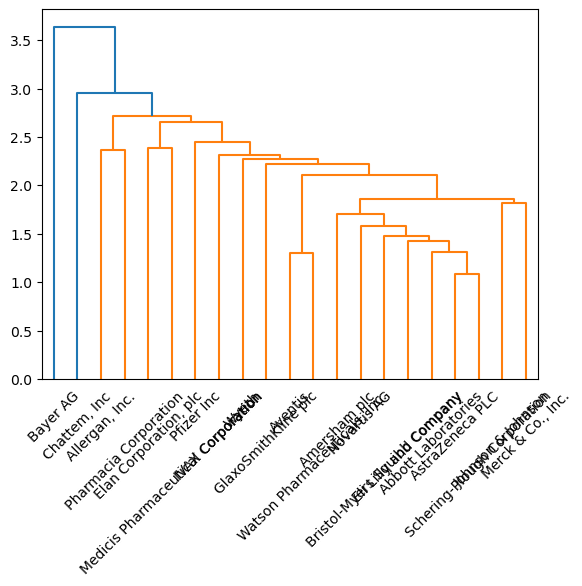

In [14]:
Z = linkage(pharm2_norm, method= 'single')
dendrogram(Z, labels=pharm2_norm.index, color_threshold=2.75)

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [35.0, 35.0, 45.0, 45.0],
  [55.0, 55.0, 65.0, 65.0],
  [40.0, 40.0, 60.0, 60.0],
  [95.0, 95.0, 105.0, 105.0],
  [85.0, 85.0, 100.0, 100.0],
  [135.0, 135.0, 145.0, 145.0],
  [125.0, 125.0, 140.0, 140.0],
  [115.0, 115.0, 132.5, 132.5],
  [92.5, 92.5, 123.75, 123.75],
  [165.0, 165.0, 175.0, 175.0],
  [155.0, 155.0, 170.0, 170.0],
  [108.125, 108.125, 162.5, 162.5],
  [75.0, 75.0, 135.3125, 135.3125],
  [50.0, 50.0, 105.15625, 105.15625],
  [195.0, 195.0, 205.0, 205.0],
  [185.0, 185.0, 200.0, 200.0],
  [77.578125, 77.578125, 192.5, 192.5],
  [12.5, 12.5, 135.0390625, 135.0390625]],
 'dcoord': [[0.0, 2.3897233834816713, 2.3897233834816713, 0.0],
  [0.0, 4.73090942673468, 4.73090942673468, 2.3897233834816713],
  [0.0, 1.8141841256586992, 1.8141841256586992, 0.0],
  [0.0, 2.447176890925988, 2.447176890925988, 0.0],
  [1.8141841256586992,
   2.6213452781912823,
   2.6213452781912823,
   2.447176890925988],
  [0.0, 1.422680

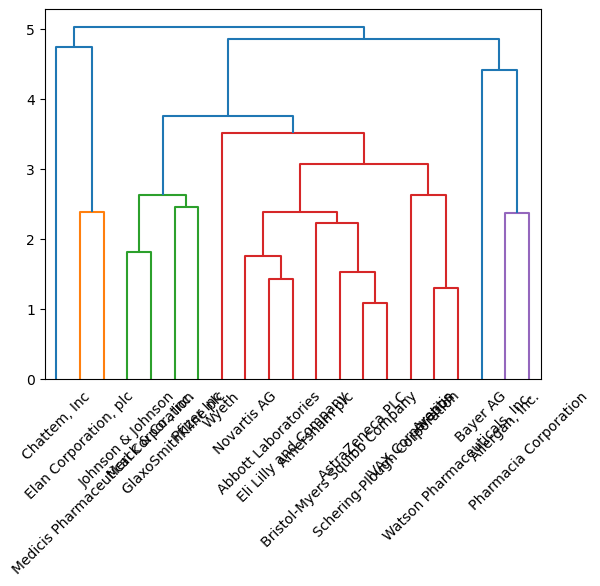

In [15]:
Z = linkage(pharm2_norm, method='average')
dendrogram(Z, labels=pharm2_norm.index, color_threshold=3.6)

In [16]:
memb = fcluster(linkage(pharm2_norm, method= 'single'), 6, criterion= 'maxclust')
memb = pdSeries(memb, index=pharm2_norm.index)
for key, item in memb.groupby(memb):
    print(key, ':', ' , '.join(item.index))

NameError: name 'pdSeries' is not defined

In [ ]:
memb = fcluster(linkage(pharm2_norm, method= 'average'), 6, criterion= 'maxclust')
memb = pd.Series(memb, index=pharm2_norm.index)
for key, item in memb.groupby(memb):
    print(key, ':', ' , '.join(item.index))

In [ ]:
pharm2_norm.index = ['{}: {}'.format(cluster, state)
                     for cluster, state in zip(memb, pharm2.index)]
sns.clustermap(pharm2_norm, method='average', col_cluster=False, cmap='mako_r')

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, random_state=0).fit(pharm2_norm)

In [ ]:
memb = pd.Series(kmeans.labels_, index=pharm2_norm.index)
for key, item in memb.groupby(memb):
    print (key, ':', ','.join(item.index))

In [ ]:

centroids = pd.DataFrame(kmeans.cluster_centers_, columns=pharm2_norm.columns)
pd.set_option('display.precision', 3)
centroids

In [ ]:
distances = kmeans.transform(pharm2_norm)

minSquaredDistances = distances.min(axis=1) ** 2

df = pd.DataFrame({'squaredDistance': minSquaredDistances, 'cluster': kmeans.labels_},
                  index=pharm2_norm.index)

for cluster, data in df.groupby('cluster'):
    count = len(data)
    withinClustSS = data.squaredDistance.sum()
    print(f'Cluster {cluster} ({count} members): {withinClustSS: 2f} within cluster')

In [ ]:
#Below this is not from EVA

In [ ]:
# 15.3
cereal = pd.read_csv('CerealsC.csv')
cereal.shape

cereal2 = cereal
print(cereal2)

In [ ]:
cereal2 = cereal2.drop(columns=['mfr', 'type'])
cereal2

In [ ]:
print(cereal.dtypes)

In [ ]:
cereal2.set_index('name', inplace=True)

In [ ]:
cereal2 = cereal2.apply(lambda x: x.astype('float64'))

In [ ]:
#cereal2 drop na
cereal2_cleaned = cereal2.dropna()
cereal2_cleaned

In [ ]:
d = pairwise.pairwise_distances(cereal2_cleaned, metric='euclidean')
pd.DataFrame(d, columns=cereal2_cleaned.index, index= cereal2_cleaned.index)

In [ ]:





######################## hopefully all below this line will work if figure out 2 columns to use

## start here and which 2 colums should be used for this comparison?

cereal2_cleaned_norm = cereal2_cleaned.apply(preprocessing.scale, axis = 0)

cereal2_cleaned_norm = cereal2_cleaned - cereal2_cleaned.mean())/ cereal2_cleaned.std()

cereal2_cleaned_norm [['Market_Cap', 'Net_Profit_Margin']]
d_norm = pairwise.pairwise_distances(cereal2_cleaned_norm[['Market_Cap', 'Net_Profit_Margin']],
                                                  metric= 'euclidean')
pd.DataFrame(d_norm, columns=cereal2_cleaned.index, index=cereal2_cleaned.index)

In [ ]:
Z = linkage(cereal2_cleaned, method= 'single')
dendrogram(Z, labels=cereal2_cleaned_norm.index, color_threshold=2.75)

In [ ]:
Z = linkage(cereal2_cleaned_norm, method='average')
dendrogram(Z, labels=cereal2_cleaned_norm.index, color_threshold=3.6)

In [ ]:
memb = fcluster(linkage(cereal2_cleaned_norm, method= 'single'), 6, criterion= 'maxclust')
memb = pdSeries(memb, index=cereal2_cleaned_norm.index)
for key, item in memb.groupby(memb):
    print(key, ':', ' , '.join(item.index))

In [ ]:
memb = fcluster(linkage(cereal2_cleaned_norm, method= 'average'), 6, criterion= 'maxclust')
memb = pd.Series(memb, index=cereal2_cleaned_norm.index)
for key, item in memb.groupby(memb):
    print(key, ':', ' , '.join(item.index))

In [ ]:
cereal2_cleaned_norm.index = ['{}: {}'.format(cluster, state)
                     for cluster, state in zip(memb, cereal2_cleaned.index)]
sns.clustermap(cereal2_cleaned_norm, method='average', col_cluster=False, cmap='mako_r')

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, random_state=0).fit(cereal2_cleaned_norm)

In [ ]:
memb = pd.Series(kmeans.labels_, index=cereal2_cleaned_norm.index)
for key, item in memb.groupby(memb):
    print (key, ':', ','.join(item.index))

In [ ]:

centroids = pd.DataFrame(kmeans.cluster_centers_, columns=cereal2_cleaned_norm.columns)
pd.set_option('display.precision', 3)
centroids

In [ ]:
distances = kmeans.transform(cereal2_cleaned_norm)

minSquaredDistances = distances.min(axis=1) ** 2

df = pd.DataFrame({'squaredDistance': minSquaredDistances, 'cluster': kmeans.labels_},
                  index=cereal2_cleaned_norm.index)

for cluster, data in df.groupby('cluster'):
    count = len(data)
    withinClustSS = data.squaredDistance.sum()
    print(f'Cluster {cluster} ({count} members): {withinClustSS: 2f} within cluster')

In [ ]:

# Make a profile plot of the centroids

centroids['cluster'] = ['Cluster {}'.format(i) for i in centroids.index]

plt.figure(figsize=(10,6))
parallel_coordinates(centroids, class_column='cluster', colormap='Dark2', linewidth=5)
plt.legend(loc='center left', bbox_to_anchor=(1,0.5))

In [ ]:
#### ignore all below

In [ ]:
utilities_df_norm = utilities_df.apply(preprocessing.scale, axis=0)

utilities_df_norm = (utilities_df - utilities_df.mean())/utilities_df.std()

utilities_df_norm[['Sales', 'Fuel_Cost']]
d_norm = pairwise.pairwise_distances(utilities_df_norm[['Sales', 'Fuel_Cost']],
                                     metric='euclidean')
pd.DataFrame(d_norm, columns=utilities_df.index, index=utilities_df.index)

In [ ]:
# within-cluster sum of squared distances and cluster counts
#  within-cluster sum of squared distances is a measure of how tightly grouped the points are around the center of the cluster (from kmeans above)

distances = kmeans.transform(cereal2_norm)

minSquaredDistances = distances.min(axis=1) **2

df = pd.DataFrame({'squaredDistance': minSquaredDistances, 'cluster': kmeans.labels_},
                  index=cereal2_norm.index)

for cluster, data in df.groupby('cluster'):
    count = len(data)
    withinClustSS = data.squaredDistance.sum()
    print(f'Cluster {cluster} ({count} members): {withinClustSS: 2f} within cluster')

In [ ]:
# below this from Emily's prior attempt

In [ ]:
# Normalize the dataframe (excluding non-numeric columns if necessary)
                             columns=pharm.select_dtypes(include=['float64', 'int64']).columns)

# Add back non-numeric columns if needed
normalized_pharm = pd.concat([normalized_pharm, pharm.select_dtypes(exclude=['float64', 'int64'])], axis=1)

print(normalized_pharm)

In [ ]:
normalized_pharm = pharm.apply(preprocessing.scale, axis=0)

In [ ]:
kmeans = KMeans(n_clusters=6, random_state=0).fit(normalized_pharm)

In [ ]:
normalized_pharm = (pharm - pharm.mean())/pharm.std()

In [ ]:
P = linkage(pharm_norm, method='single')
dendrogram(P, labels=pharm_norm.index, color_threshold=2.75

In [ ]:

# 15.3
cereal = pd.read_csv('Cereals.csv')
cereal.shape

cereal2 = cereal
print(cereal2)

In [ ]:
cereal2_cleaned = cereal2.dropna()

In [ ]:
# intitialize the scaler
scaler = MinMaxScaler()

In [ ]:
# Normalize the dataframe (excluding non-numeric columns if necessary)
normalized_df = pd.DataFrame(scaler.fit_transform(cereal2_cleaned.select_dtypes(include=['float64', 'int64'])), 
                             columns=cereal2_cleaned.select_dtypes(include=['float64', 'int64']).columns)

# Add back non-numeric columns if needed
normalized_df = pd.concat([normalized_df, cereal2_cleaned.select_dtypes(exclude=['float64', 'int64'])], axis=1)

print(normalized_df)

In [ ]:
normalized_df[['calories','protein','sugars']]

In [ ]:
d_norm = pairwise.pairwise_distances(normalized_df[['calories','protein','sugars']],
            metric='euclidean')
pd.DafaFrame(d_norm, columns=normalized_df.index, index=normalized_df.index)

In [ ]:
import numpy as np

Z = linkage(normalized_df, method='single')     # this is the single method
dendrogram(Z, labels=normalized_df.index, color_threshold=2.75)

In [ ]:
Z = linkage(normalized_df, method='average')             # this is the average method
dendrogram(Z, labels=normalized_df.index, color_threshold=3.6)

In [ ]:
# intitialize a different scaler
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()

In [ ]:
# Normalize the dataframe
cereal2_cleaned_norm = pd.DataFrame(scaler.fit_transform(cereal2_cleaned.select_dtypes(include=['float64', 'int64'])), 
                                columns=cereal2_cleaned.select_dtypes(include=['float64', 'int64']).columns)

# Add back non-numeric columns if needed
cereal2_cleaned = pd.concat([cereal2_cleaned, cereal2_cleaned.select_dtypes(exclude=['float64', 'int64'])], axis=1)
print(cereal2_cleaned_norm)

In [ ]:
Z = linkage(cereal2_cleaned_norm, method='average')             # this is the average method
dendrogram(Z, labels=cereal2_cleaned_norm.index, color_threshold=3.6

In [ ]:
Z = linkage(cereal2_cleaned_norm, method='single')     # this is the single method
dendrogram(Z, labels=cereal2_cleaned_norm.index, color_threshold=2.75)

In [ ]:
distances = kmeans.transform(cereal2_cleaned_norm)

In [ ]:

d = pairwise.pairwise_distances(utilities_df, metric='euclidean')
pd.DataFrame(d, columns=utilities_df.index, index=utilities_df.index)


In [ ]:
cereal2_cleaned.groupby(cluster).mean()